In [9]:
from pathlib import Path
import re
import pandas as pd

import statistics
import math

from utils.helpers import load_dataset

# I. Preprocessing and tokenization with UDPipe

In [7]:
# text normalization

def normalize_text(text: str) -> str:
    if not text:
        return ""
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample = '  ahoj,\n\n   toto   je   test.\n\n  '
print("original:", repr(sample))
print("normalized:", repr(normalize_text(sample)))

ORIGINAL: '  ahoj,\n\n   toto   je   test.\n\n  '
NORMALIZED: 'ahoj, toto je test.'


In [28]:
from ufal.udpipe import Model
from ufal.udpipe import Pipeline, ProcessingError

MODEL_PATH = r"udpipe\czech-fictree-ud-2.5-191206.udpipe"


In [31]:
# initialize the UDPipe model
model = Model.load(MODEL_PATH)
print("[1/2]model initialized" if model is not None else "model NOT initialized")

#building pipeline
pipeline = Pipeline(
    model,
    "tokenize",          # input is raw text
    Pipeline.DEFAULT,    # tagging
    Pipeline.DEFAULT,    # parsing
    "conllu"             # output format
)
print("[2/2]pipeline built")

[1/2]model initialized
[2/2]pipeline built


In [37]:
# converting conllu
def conllu_to_tokens(conllu_text: str) -> list[dict]:
    """ converts ConLLU format into usable python dictionary (only a subset of attributes is used)"""
    tokens = []

    for line in conllu_text.splitlines():
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        cols = line.split("\t")
        if len(cols) != 10:
            continue

        token_id = cols[0]

        # skip multiword tokens like 1-2 and empty nodes like 3.1
        if "-" in token_id or "." in token_id:
            continue

        tokens.append({
            "form": cols[1],
            "lemma": cols[2],
            "upos": cols[3],
        })

    return tokens

# wrapping into one function
def parse_text_to_tokens(text: str) -> list[dict]:
    """wrapper function to process text into tokens"""
    if not text:
        return []

    error = ProcessingError()
    conllu = pipeline.process(text, error)

    if error.occurred():
        raise RuntimeError(error.message)

    return conllu_to_tokens(conllu)

In [33]:
# test example
text = "Mluvčí: Kdyby tehdy přišel včas, všechno mohlo dopadnout jinak."
tokens = parse_text_to_tokens(text)

print("number of tokens:", len(tokens))
for tok in tokens:
    print(tok)

number of tokens: 13
{'form': 'Mluvčí', 'lemma': 'Mluvčit', 'upos': 'VERB'}
{'form': ':', 'lemma': ':', 'upos': 'PUNCT'}
{'form': 'Když', 'lemma': 'když', 'upos': 'SCONJ'}
{'form': 'by', 'lemma': 'být', 'upos': 'AUX'}
{'form': 'tehdy', 'lemma': 'tehdy', 'upos': 'ADV'}
{'form': 'přišel', 'lemma': 'přijít', 'upos': 'VERB'}
{'form': 'včas', 'lemma': 'včas', 'upos': 'ADV'}
{'form': ',', 'lemma': ',', 'upos': 'PUNCT'}
{'form': 'všechno', 'lemma': 'všechen', 'upos': 'DET'}
{'form': 'mohlo', 'lemma': 'moci', 'upos': 'VERB'}
{'form': 'dopadnout', 'lemma': 'dopadnout', 'upos': 'VERB'}
{'form': 'jinak', 'lemma': 'jinak', 'upos': 'ADV'}
{'form': '.', 'lemma': '.', 'upos': 'PUNCT'}


# II. Measuting Average Token Length

In [36]:
# count tokens
def count_parsed_tokens(tokens: list[dict], exclude_punct: bool = True) -> int:
    """count tokens from an already parsed token list."""
    if exclude_punct:
        return sum(1 for tok in tokens if tok["upos"] != "PUNCT")
    return len(tokens)

# another example
text = "Mluvčí: Kdyby tehdy přišel včas, všechno mohlo dopadnout jinak."
tokens = parse_text_to_tokens(text)

print(tokens)
print("Including punctuation:", count_parsed_tokens(tokens, exclude_punct=False))
print("Excluding punctuation:", count_parsed_tokens(tokens, exclude_punct=True))

[{'form': 'Mluvčí', 'lemma': 'Mluvčit', 'upos': 'VERB'}, {'form': ':', 'lemma': ':', 'upos': 'PUNCT'}, {'form': 'Když', 'lemma': 'když', 'upos': 'SCONJ'}, {'form': 'by', 'lemma': 'být', 'upos': 'AUX'}, {'form': 'tehdy', 'lemma': 'tehdy', 'upos': 'ADV'}, {'form': 'přišel', 'lemma': 'přijít', 'upos': 'VERB'}, {'form': 'včas', 'lemma': 'včas', 'upos': 'ADV'}, {'form': ',', 'lemma': ',', 'upos': 'PUNCT'}, {'form': 'všechno', 'lemma': 'všechen', 'upos': 'DET'}, {'form': 'mohlo', 'lemma': 'moci', 'upos': 'VERB'}, {'form': 'dopadnout', 'lemma': 'dopadnout', 'upos': 'VERB'}, {'form': 'jinak', 'lemma': 'jinak', 'upos': 'ADV'}, {'form': '.', 'lemma': '.', 'upos': 'PUNCT'}]
Including punctuation: 13
Excluding punctuation: 10


In [ ]:
# another wrapper
def count_tokens_in_text(text: str, exclude_punct: bool = True) -> int:
    """parse text and count its tokens."""
    tokens = parse_text_to_tokens(text)
    return count_parsed_tokens(tokens, exclude_punct=exclude_punct)

In [44]:
def compute_item_length_metrics(item: dict, exclude_punct: bool = True) -> dict:
    """
    compute token-length metrics for a single dataset item 

    uses fields:
    - context
    - utterance
    - options
    
    """

    # main text fields
    context = item.get("context", "") or ""
    utterance = item.get("utterance", "") or ""
    options = item.get("options", []) or []

    # parse once
    context_tokens = parse_text_to_tokens(context)
    utterance_tokens = parse_text_to_tokens(utterance)
    option_token_lists = [
        parse_text_to_tokens(opt.get("text", "") or "")
        for opt in options
    ]

    # count
    context_length = count_parsed_tokens(context_tokens, exclude_punct=exclude_punct)
    utterance_length = count_parsed_tokens(utterance_tokens, exclude_punct=exclude_punct)

    option_lengths = [
        count_parsed_tokens(tokens, exclude_punct=exclude_punct)
        for tokens in option_token_lists
    ]

    options_total_length = sum(option_lengths)
    options_mean_length = options_total_length / len(option_lengths) if option_lengths else 0

    item_total_length = (
        context_length
        + utterance_length
        + options_total_length
    )

    metadata = item.get("metadata", {}) or {}

    return {
        "id": item.get("id", ""),
        "phenomenon": item.get("phenomenon", ""),
        "category": item.get("category", ""),
        "context_length": context_length,
        "utterance_length": utterance_length,
        "options_total_length": options_total_length,
        "options_mean_length": options_mean_length,
        "item_total_length": item_total_length,
    }

In [45]:
# information structure
items = load_dataset(r"data\information-structure\eval\inf_structure_eval_720_v1.json")
print("loaded items:", len(items))

one_result = compute_item_length_metrics(items[0])
one_result

loaded items: 720


{'id': 'information-structure-baseline-1-focus_object',
 'phenomenon': 'information_structure',
 'category': 'baseline_focus_object',
 'context_length': 17,
 'utterance_length': 5,
 'options_total_length': 18,
 'options_mean_length': 4.5,
 'item_total_length': 40}

In [46]:
# presupposition
items = load_dataset(r"data\presupposition\eval\presupposition-accusative-60.json")
print("loaded items:", len(items))

one_result = compute_item_length_metrics(items[0])
one_result

loaded items: 60


{'id': 'presupposition-accusative-1',
 'phenomenon': 'presupposition',
 'category': 'accusative',
 'context_length': 11,
 'utterance_length': 14,
 'options_total_length': 31,
 'options_mean_length': 7.75,
 'item_total_length': 56}

In [47]:
# implicature
items = load_dataset(r"data\implicature\eval\eval_circa_indirect_answer_binary_550.json")
print("loaded items:", len(items))

one_result = compute_item_length_metrics(items[0])
one_result

loaded items: 550


{'id': 'circa-indirect_answer-5',
 'phenomenon': 'implicature',
 'category': 'indirect_answer_binary',
 'context_length': 8,
 'utterance_length': 10,
 'options_total_length': 26,
 'options_mean_length': 6.5,
 'item_total_length': 44}

In [113]:
def compute_dataset_length_metrics(items: list[dict], exclude_punct: bool = True) -> pd.DataFrame:
    """compute item-level length metrics for the whole dataset"""
    rows = [
        compute_item_length_metrics(item, exclude_punct=exclude_punct)
        for item in items
    ]
    return pd.DataFrame(rows)


def aggregate_length_metrics(df: pd.DataFrame, group_by: str | list[str]) -> pd.DataFrame:
    """aggregate length metrics by selected grouping columns"""
    if isinstance(group_by, str):
        group_by = [group_by] 

    metric_cols = [
        "context_length",
        "utterance_length",
        "options_total_length",
        "options_mean_length",
        "item_total_length",
    ]

    return (
        df.groupby(group_by)[metric_cols]
        .agg(["mean", "median", "std", "min", "max"])
        .round(2)
    )


def summarize_length_metrics(df: pd.DataFrame) -> pd.Series:
    """return simple global mean values for the whole dataset."""
    metric_cols = [
        "context_length",
        "utterance_length",
        "options_total_length",
        "options_mean_length",
        "item_total_length",
    ]
    return (
        df[metric_cols]
        .agg(["mean", "median", "std", "min", "max"])
        .round(2)
    )

In [115]:
items = load_dataset(r"data\information-structure\eval\inf_structure_eval_720.json")

df_lengths = compute_dataset_length_metrics(items)

global_summary = summarize_length_metrics(df_lengths)
cat_summary = aggregate_length_metrics(df_lengths, "category")

print("global:")
print(global_summary)
print()

print("by category:")
print(cat_summary)
print()

global:
        context_length  utterance_length  options_total_length  \
mean             20.54              4.35                 12.04   
median           22.00              5.00                 12.00   
std               3.85              0.92                  0.36   
min              13.00              3.00                 12.00   
max              28.00              5.00                 16.00   

        options_mean_length  item_total_length  
mean                   3.01              36.94  
median                 3.00              37.00  
std                    0.09               3.56  
min                    3.00              30.00  
max                    4.00              45.00  

by category:
                  context_length                      utterance_length         \
                            mean median   std min max             mean median   
category                                                                        
baseline                   15.79   16.0  1.6

In [126]:
df_lengths.columns

Index(['id', 'phenomenon', 'category', 'context_length', 'utterance_length',
       'options_total_length', 'options_mean_length', 'item_total_length'],
      dtype='object')

In [112]:
# TODO 
# evaluate on all 3 sets (all phenomena)
# visualize

# III. Measuring Lemma Frequency

In [120]:
TOTAL_CORPUS_SIZE_SYN2025 = 122_072_831 # total size of SYN2025 (info directly from KonText)
LOW_FREQUENCY_THRESHOLD = 1000 # we consider lemmas with frequency below this threshold to be "low-frequency"

In [74]:
# we will use frequency table to extract lemma frequencies

import pandas as pd


def load_frequency_table_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        sep=";",
        header=None,
        names=["rank", "lemma", "freq"],
        quotechar='"',
        encoding="utf-8"
    )

    df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
    df["lemma"] = df["lemma"].astype(str).str.strip()
    df["freq"] = pd.to_numeric(df["freq"], errors="coerce")

    df = df.dropna(subset=["rank", "lemma", "freq"])

    return df


def frequency_df_to_dict(df: pd.DataFrame) -> dict:
    return dict(zip(df["lemma"], df["freq"]))

In [76]:
# load the freq list from csv
freq_df = load_frequency_table_df("kontext_freq_list.csv")
print(freq_df.head(5))

   rank lemma     freq
0     1   být  4315494
1     2     a  3196116
2     3    se  3048890
3     4     v  2315653
4     5    na  1839522


In [101]:
# create a dictionary of lemma frequencies
freq_dict = frequency_df_to_dict(freq_df)
for lemma in freq_df.head(5)["lemma"].tolist():
    print(lemma, freq_dict.get(lemma))

FREQUENCY_DICT = freq_dict

být 4315494
a 3196116
se 3048890
v 2315653
na 1839522


In [102]:
LEXICAL_POS = {"NOUN", "VERB", "ADJ", "ADV"} # PoS that we consider to be among the lexical ones

def extract_lemmas_for_freq(
    tokens: list[dict],
    lexical_only: bool = True, # takes only lexical lemmas (from a predefined list)
    exclude_propn: bool = True,
) -> list[str]:
    """extract lemmas from parsed tokens for frequency analysis"""

    lemmas = []

    for tok in tokens:
        upos = tok["upos"]
        lemma = tok["lemma"].lower().strip()

        if upos == "PUNCT":
            continue

        if exclude_propn and upos == "PROPN":
            continue

        if lexical_only and upos not in LEXICAL_POS:
            continue

        lemmas.append(lemma)

    return lemmas

def map_lemmas_to_freq(
    lemmas: list[str],
    freq_dict: dict,
) -> tuple[list[int], list[str]]:
    """
    map lemmas to frequencies; 
    return:
    - matched frequencies
    - out-of-vocabulary (oov) lemmas
    """

    freqs = []
    oov = []

    for lemma in lemmas:
        if lemma in freq_dict:
            freqs.append(freq_dict[lemma])
        else:
            oov.append(lemma)

    return freqs, oov

In [116]:
# exmaple
example_tokens = parse_text_to_tokens("Ano, je to pravda: Griff také pohlédl na hodinky.")
lemmas = extract_lemmas_for_freq(example_tokens)
print(lemmas)

['pravda', 'griff', 'také', 'pohlédnout', 'hodinky']


In [117]:
# test the mapping function
freqs = map_lemmas_to_freq(lemmas, freq_dict)
print(lemmas)
print(freqs)

['pravda', 'griff', 'také', 'pohlédnout', 'hodinky']
([31060, 953, 201777, 7668, 3356], [])


In [121]:
def _round3(x):
    return round(x, 3) if isinstance(x, float) else x


def compute_freq_stats(
    freqs: list[int],
    oov: list[str] = [], # empty oov by default
    total_corpus_size: int = TOTAL_CORPUS_SIZE_SYN2025,
    low_freq_threshold: int = LOW_FREQUENCY_THRESHOLD
) -> dict:
    """compute summary statistics from matched lemma frequencies"""

    n_freqs = len(freqs)
    n_oov = len(oov)
    n_total = n_freqs + n_oov

    if n_freqs == 0:
        return {
            "n_lemmas_matched": 0,
            "n_oov": n_oov,
            "oov_ratio": _round3(n_oov / n_total) if n_total else 0.0,
            "mean_freq": None,
            "median_freq": None,
            "mean_log_freq": None,
            "median_log_freq": None,
            "mean_rel_freq_pm": None,
            "low_freq_ratio": None,
        }

    # log frequencies
    log_freqs = [math.log1p(f) for f in freqs]

    # relative frequency per million tokens
    rel_freqs = [(f / total_corpus_size) * 1_000_000 for f in freqs]

    # low-frequency ratio
    low_freq_count = sum(1 for f in freqs if f < low_freq_threshold)
    low_freq_ratio = low_freq_count / n_freqs

    return {
        "n_lemmas_matched": n_freqs,
        "n_oov": n_oov,
        "oov_ratio": _round3(n_oov / n_total) if n_total else 0.0,
        "mean_freq": _round3(statistics.mean(freqs)),
        "median_freq": _round3(statistics.median(freqs)),
        "mean_log_freq": _round3(statistics.mean(log_freqs)),
        "median_log_freq": _round3(statistics.median(log_freqs)),
        "mean_rel_freq_pm": _round3(statistics.mean(rel_freqs)),
        "low_freq_ratio": _round3(low_freq_ratio),
    }

In [122]:
# another test
text = "Vypravěčka popisuje noční návrat na hřbitov a své dojmy z prostředí."

# extract tokens
tokens_ex = parse_text_to_tokens(text)

# extract lemmas from tokens
lemmas_ex = extract_lemmas_for_freq(tokens_ex)

# map lemmas to frequencies 
freqs_ex, oov_ex = map_lemmas_to_freq(lemmas_ex, freq_dict)

# compute statistics
results = compute_freq_stats(freqs_ex, oov_ex)

# return results
results


{'n_lemmas_matched': 7,
 'n_oov': 0,
 'oov_ratio': 0.0,
 'mean_freq': 10445.857,
 'median_freq': 10302,
 'mean_log_freq': 8.64,
 'median_log_freq': 9.24,
 'mean_rel_freq_pm': 85.571,
 'low_freq_ratio': 0.143}

In [145]:
# item-level computation

def compute_item_frequency_metrics(
    item: dict,
    freq_dict: dict = FREQUENCY_DICT,
    lexical_only: bool = False,
    exclude_propn: bool = True,
    debug_oov: bool = True # if set to True, list of oovs is included in the return
) -> dict:
    """compute frequency-based metrics for a single dataset item"""

    context = item.get("context", "") or ""
    utterance = item.get("utterance", "") or ""

    # parsing text to tokens
    context_tokens = parse_text_to_tokens(context)
    utterance_tokens = parse_text_to_tokens(utterance)

    # merging tokens
    all_tokens = context_tokens + utterance_tokens

    # extracting lemmas from tokens
    lemmas = extract_lemmas_for_freq(
        all_tokens,
        lexical_only=lexical_only,
        exclude_propn=exclude_propn,
    )

    # map lemmas to their frequencies
    freqs, oov = map_lemmas_to_freq(lemmas, freq_dict)

    # compute statistics
    stats = compute_freq_stats(freqs, oov)

    return {
        "id": item.get("id", ""),
        "phenomenon": item.get("phenomenon", ""),
        "category": item.get("category", ""),
        **stats,
        "oov_list": oov if debug_oov is True else None
    }

In [158]:
# test on teal items

data_inf = load_dataset(r"data\information-structure\eval\inf_structure_eval_720.json")
ex = data[0]
ex

{'id': 'information-structure-17-focus_object',
 'creation_method': 'generation',
 'phenomenon': 'information_structure',
 'category': 'baseline',
 'context': 'Z kuchyně bylo cítit, že kuchař sice něco připálil, ale nebylo jasné, o jaký pokrm vlastně šlo.',
 'utterance': 'Marek na to najednou prohlásil:',
 'options': [{'label': 'A',
   'type': 'object_last',
   'text': 'Kuchař připálil omáčku.'},
  {'label': 'B', 'type': 'subject_last', 'text': 'Omáčku připálil kuchař.'},
  {'label': 'C', 'type': 'verb_last', 'text': 'Kuchař omáčku připálil.'},
  {'label': 'D', 'type': 'distractor', 'text': 'Kuchař otevřel troubu.'}],
 'gold_label': 'A',
 'metadata': {'cue': 'baseline', 'case': 'focus_object', 'scenario_id': 17}}

In [147]:
stats = compute_item_frequency_metrics(ex)
stats

{'id': 'information-structure-17-focus_object',
 'phenomenon': 'information_structure',
 'category': 'baseline',
 'n_lemmas_matched': 21,
 'n_oov': 0,
 'oov_ratio': 0.0,
 'mean_freq': 746373.095,
 'median_freq': 67740,
 'mean_log_freq': 11.379,
 'median_log_freq': 11.123,
 'mean_rel_freq_pm': 6114.162,
 'low_freq_ratio': 0.048,
 'oov_list': []}

In [156]:
# dataset-level computation

def compute_dataset_frequency_metrics(
    items: list[dict],
    freq_dict: dict = FREQUENCY_DICT,
    lexical_only: bool = False,
    exclude_propn: bool = True,
) -> pd.DataFrame:
    """compute item-level frequency metrics for the whole dataset"""

    rows = [
        compute_item_frequency_metrics(
            item,
            freq_dict=freq_dict,
            lexical_only=lexical_only,
            exclude_propn=exclude_propn,
        )
        for item in items
    ]

    return pd.DataFrame(rows)

In [157]:
stats = compute_dataset_frequency_metrics(data)

In [152]:
stats[stats['oov_list'].astype(str) != '[]' ].head()

,id,phenomenon,category,n_lemmas_matched,n_oov,oov_ratio,mean_freq,median_freq,mean_log_freq,median_log_freq,mean_rel_freq_pm,low_freq_ratio,oov_list
9,information-structure-20-focus_object,information_structure,baseline,19,1,0.050,495041.474,67740.0,11.324,11.123,4055.296,0.105,[ondřát]
10,information-structure-20-focus_subject,information_structure,baseline,21,3,0.125,673821.952,60441.0,11.511,11.009,5519.836,0.048,"[loga, mait, ondřát]"
11,information-structure-20-focus_verb,information_structure,baseline,22,1,0.043,675934.591,83640.0,11.594,11.294,5537.142,0.045,[ondřát]
27,information-structure-26-focus_object,information_structure,baseline,20,2,0.091,712437.900,50035.5,11.542,10.754,5836.171,0.000,"[ředitet, lukat]"
28,information-structure-26-focus_subject,information_structure,baseline,19,1,0.050,645774.579,58072.0,11.287,10.969,5290.076,0.053,[lukat]


In [134]:
# metric ols are fixed

METRIC_COLS = [
        "mean_freq",
        "median_freq",
        "mean_log_freq",
        "median_log_freq",
        "mean_rel_freq_pm",
        "low_freq_ratio",
        "oov_ratio",
    ]

In [142]:
def aggregate_frequency_metrics(
    df: pd.DataFrame,
    group_by: str | list[str],
    metric_cols: list[str] = METRIC_COLS
) -> pd.DataFrame:
    """aggregate frequency metrics by selected grouping columns"""

    if isinstance(group_by, str):
        group_by = [group_by]

    return (
        df.groupby(group_by)[metric_cols]
        .agg(["mean", "median", "std", "min", "max"])
        .round(3)
    )

In [143]:
def summarize_frequency_metrics(df: pd.DataFrame, metric_cols: list[str] = METRIC_COLS) -> pd.DataFrame:
    """return global summary statistics for the whole dataset"""
    return (
        df[metric_cols]
        .agg(["mean", "median", "std", "min", "max"])
        .round(3)
    )

In [159]:
# test

# total
df_freq = compute_dataset_frequency_metrics(data_inf, freq_dict)

# by category
agg_cat = aggregate_frequency_metrics(df_freq, "category")

# global
summary = summarize_frequency_metrics(df_freq)

In [160]:
summary

,mean_freq,median_freq,mean_log_freq,median_log_freq,mean_rel_freq_pm,low_freq_ratio,oov_ratio
mean,685245.750,110525.233,11.480,11.437,5613.417,0.047,0.018
median,696475.158,99200.000,11.497,11.470,5705.406,0.043,0.000
std,168797.949,71828.079,0.372,0.524,1382.764,0.048,0.030
min,238863.480,31863.000,10.127,10.369,1956.729,0.000,0.000
max,1213137.696,566212.000,12.372,13.247,9937.819,0.190,0.167


In [170]:
df_freq.head()

,id,phenomenon,category,n_lemmas_matched,n_oov,oov_ratio,mean_freq,median_freq,mean_log_freq,median_log_freq,mean_rel_freq_pm,low_freq_ratio,oov_list
0,information-structure-17-focus_object,information_structure,baseline,21,0,0.0,746373.095,67740.0,11.379,11.123,6114.162,0.048,[]
1,information-structure-17-focus_subject,information_structure,baseline,19,0,0.0,757284.474,147108.0,11.616,11.899,6203.546,0.053,[]
2,information-structure-17-focus_verb,information_structure,baseline,21,0,0.0,706613.714,106839.0,11.715,11.579,5788.460,0.000,[]
3,information-structure-18-focus_object,information_structure,baseline,24,0,0.0,613936.833,32097.0,11.160,10.377,5029.267,0.083,[]
4,information-structure-18-focus_subject,information_structure,baseline,20,0,0.0,557172.800,93690.0,11.556,11.423,4564.265,0.050,[]


## visulization

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt


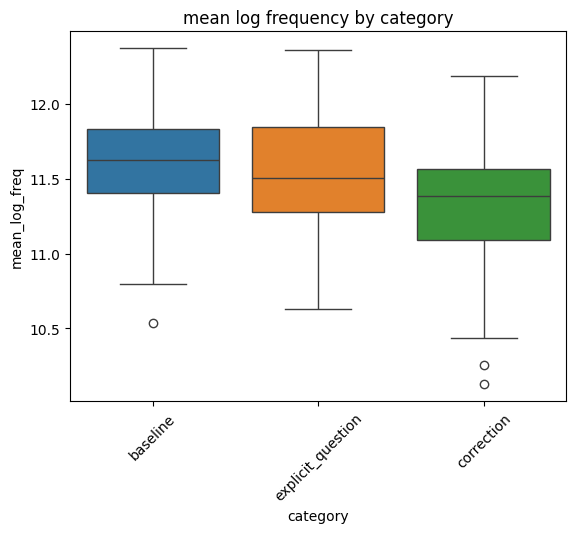

In [172]:
sns.boxplot(
    data=df_freq,
    x="category",
    y="mean_log_freq",
    hue="category"
)

plt.xticks(rotation=45)
plt.title("mean log frequency by category")
plt.show()

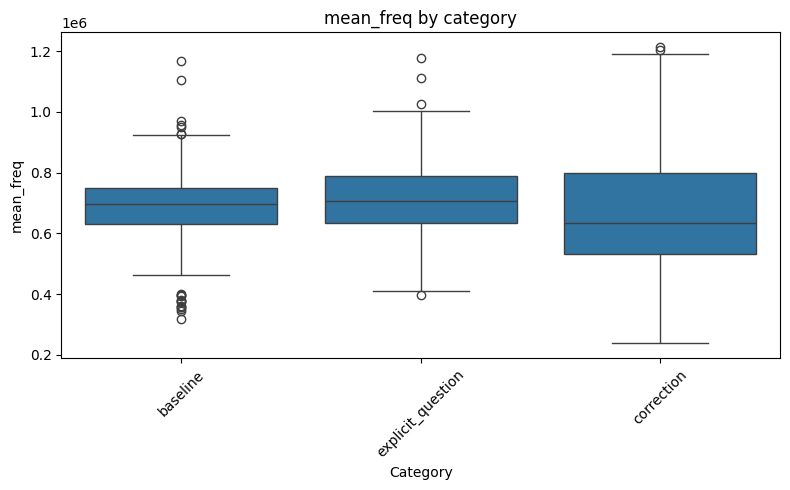

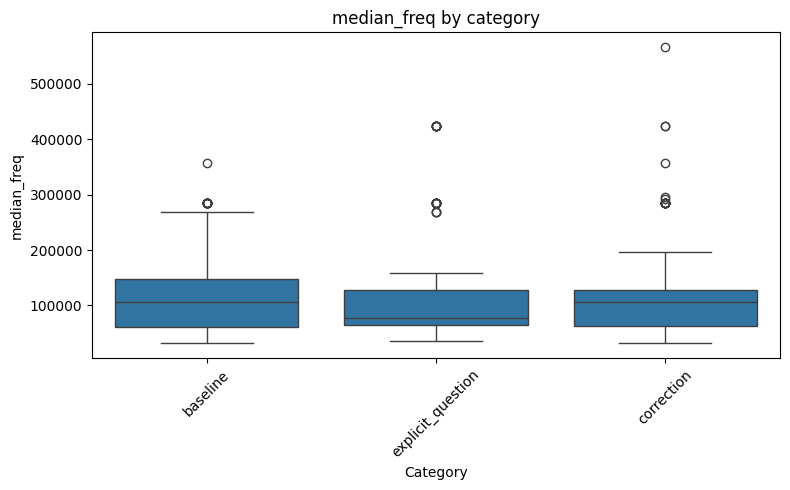

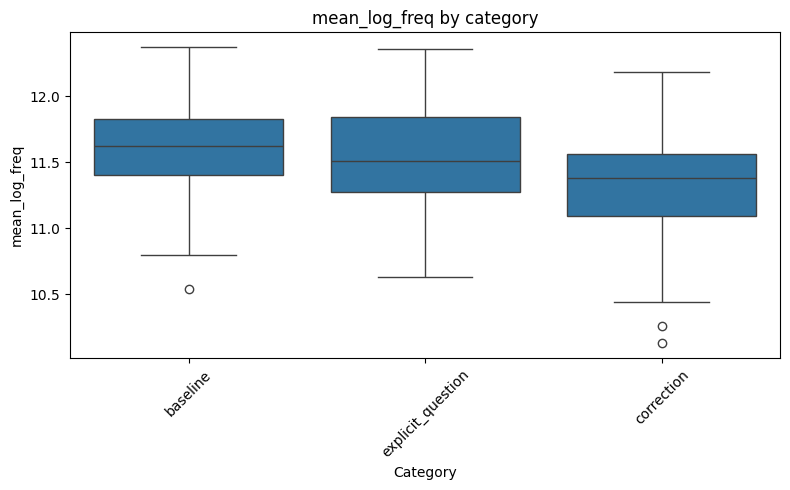

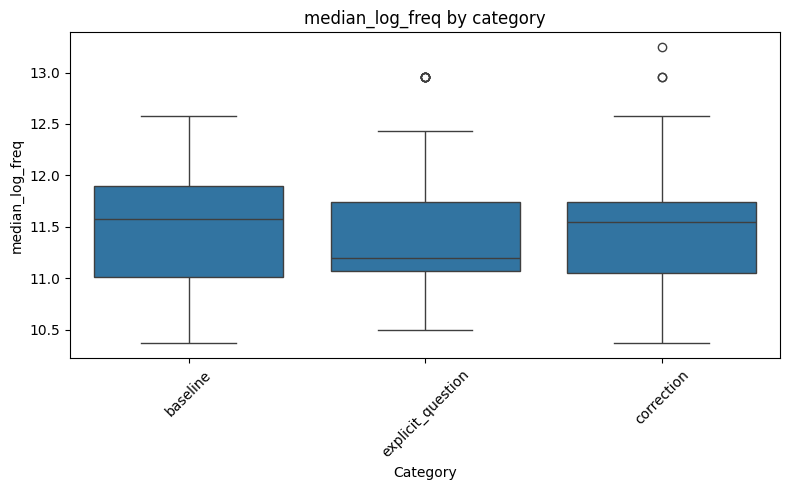

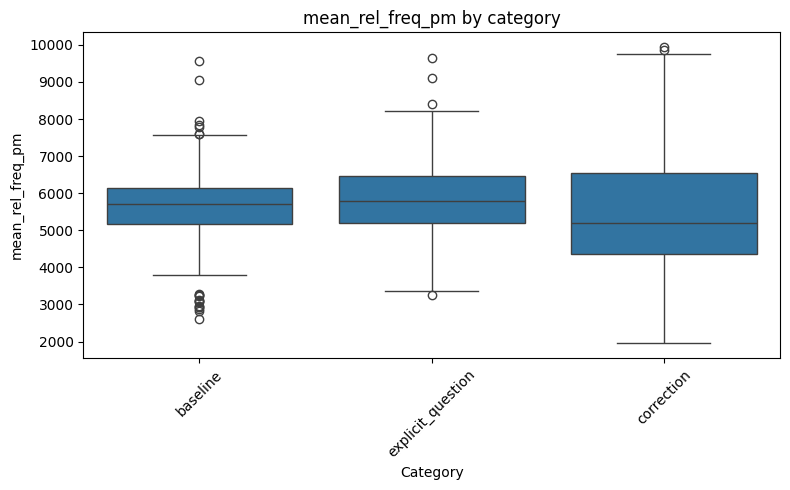

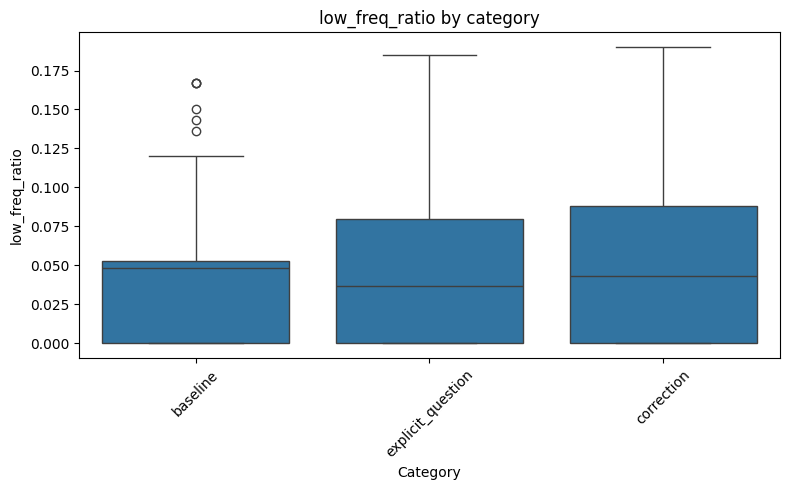

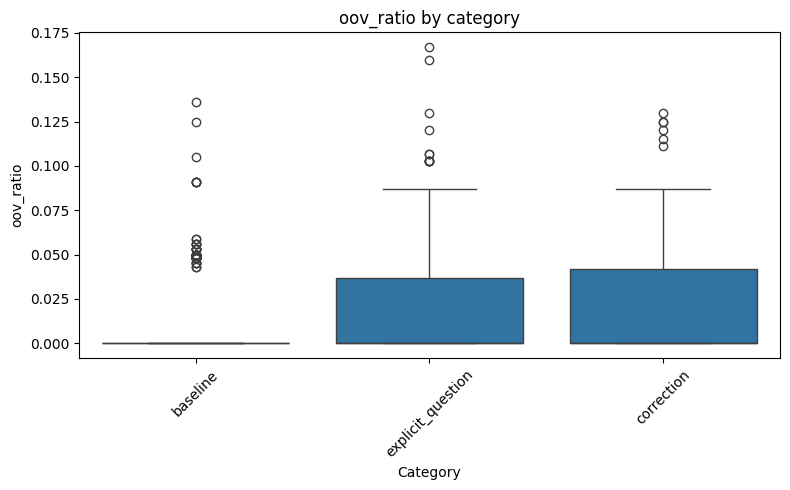

In [167]:
for metric in METRIC_COLS:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df_freq,
        x="category",
        y=metric,
    )

    plt.xticks(rotation=45)
    plt.title(f"{metric} by category")
    plt.xlabel("Category")
    plt.ylabel(metric)

    plt.tight_layout()
    plt.show()

In [139]:
data = load_dataset(r"data\presupposition\eval\presupposition-counterfactual-60.json")

In [140]:
# test

# total
df_freq = compute_dataset_frequency_metrics(data, freq_dict)

# by category
agg_cat = aggregate_frequency_metrics(df_freq, "category")

# global
summary = summarize_frequency_metrics(df_freq)

In [141]:
summary

,mean_freq,median_freq,mean_log_freq,median_log_freq,mean_rel_freq_pm,low_freq_ratio,oov_ratio
mean,1047209.160,209658.808,11.676,11.996,8578.560,0.062,0.070
median,1065358.703,161315.750,11.732,11.976,8727.238,0.056,0.053
std,191860.171,138162.732,0.525,0.724,1571.686,0.055,0.052
min,565724.958,35379.000,10.414,10.474,4634.323,0.000,0.000
max,1544266.964,589067.000,12.880,13.286,12650.374,0.241,0.250


In [174]:
# TODO
# make stats and plots for 1) length-related 2) frequency-related stats + plot them for all 3 phenomena

# maybe: refactor code; in length and freq sections some functions repeat 